This notebook is a simulation of the parcellation problem. In this notebook we start with a true U with 5 parcels. 

I this simulation I rely on a larger number of potential task - picking task batteries of 3 to 28 tasks.

In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import construct as ct
import itertools
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests


In [2]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
base_dir = 'Y:/data'

# start with some U_true, in this simulation 5 parcels

In [3]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [4]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [5]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

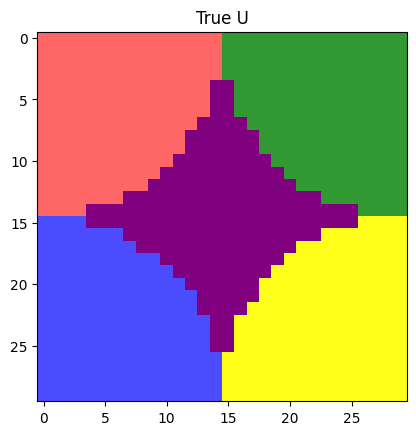

In [6]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5,device=device, dtype=pt.float64)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5.cpu().numpy(), title = 'True U')

# run analysis

In [20]:
D = sim.sim_parcellation(num_task_lib = 100,
                     n_parcels = 5,
                     U_true = U_true_5,
                     battery_sizes = [3,4,6,8,10,14,18,24,28],
                     n_batteries = 10000,
                     base_noise = 1,
                     collapsed_U_true = None,
                     n_sim = 50,
                     seed = None)

Processing battery size: 3
Processing battery size: 4
Processing battery size: 6
Processing battery size: 8
Processing battery size: 10
Processing battery size: 14
Processing battery size: 18
Processing battery size: 24
Processing battery size: 28


In [23]:
D.to_csv('parcellation_sim.tsv', index=False,sep='\t')

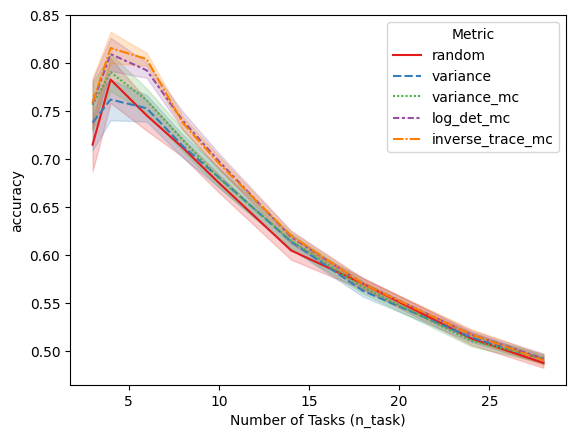

In [22]:
sns.lineplot(data=D,x="n_task", y="accuracy", hue="metric", style='metric',palette="Set1")
plt.xlabel("Number of Tasks (n_task)")
plt.ylabel("accuracy")
plt.legend(title="Metric")
plt.show()